### Titanic Inferential Statistics

### Inferential idea: Assuming this data as a sample dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

### Import dataset

In [ ]:
# Import data using pandas
titanic= pd.read_csv("https://raw.githubusercontent.com/shans28/pandas-viz-stats-practice/refs/heads/main/data/train.csv")
titanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Compute mean of Survived

In [ ]:
survival_rate = titanic["Survived"].mean()
survival_rate

np.float64(0.3838383838383838)

### Computing confidence interval for survival rate


In [ ]:
sample = titanic.sample(200, random_state=42)
p_hat = sample["Survived"].mean()
n = len(sample)

# 95% confidence interval for population proportion
z = stats.norm.ppf(0.975)  # z-score for 95%
margin_error = z * np.sqrt((p_hat*(1-p_hat))/n)
conf_interval = (p_hat - margin_error, p_hat + margin_error)

print(f"\nInferential: Estimated survival rate = {p_hat:.3f}")
print(f"95% Confidence Interval = {conf_interval}")


Inferential: Estimated survival rate = 0.405
95% Confidence Interval = (np.float64(0.3369670837271852), np.float64(0.47303291627281485))


### Hypothesis Testing

In [ ]:
 #(a) Chi-Square Test: Is survival independent of passenger class?
contingency = pd.crosstab(titanic["Pclass"], titanic["Survived"])
chi2, p, dof, expected = stats.chi2_contingency(contingency)

print("\nChi-Square Test (Survival vs. Pclass):")
print(f"Chi2 = {chi2:.2f}, p-value = {p:.5f}")
if p < 0.05:
    print("➡ Reject null hypothesis: Survival depends on class.")
else:
    print("➡ Fail to reject null: No evidence survival depends on class.")


Chi-Square Test (Survival vs. Pclass):
Chi2 = 102.89, p-value = 0.00000
➡ Reject null hypothesis: Survival depends on class.


In [ ]:
# (b) T-Test: Did men and women have different ages on average?
male_ages = titanic[titanic["Sex"]=="male"]["Age"].dropna()
female_ages = titanic[titanic["Sex"]=="female"]["Age"].dropna()

t_stat, p_val = stats.ttest_ind(male_ages, female_ages, equal_var=False)

print("\nT-Test (Male vs. Female Age):")
print(f"T = {t_stat:.2f}, p = {p_val:.5f}")
if p_val < 0.05:
    print("➡ Reject null: Significant age difference between genders.")
else:
    print("➡ Fail to reject null: No significant difference.")


T-Test (Male vs. Female Age):
T = 2.53, p = 0.01181
➡ Reject null: Significant age difference between genders.


### Simple Linear Regression (Age - Fare relation)

In [ ]:

from sklearn.linear_model import LinearRegression

df_clean = titanic[["Age", "Fare"]].dropna()

X = df_clean[["Age"]]
y = df_clean["Fare"]

model = LinearRegression()
model.fit(X, y)

print("\nRegression (Fare ~ Age):")
print(f"Coefficient (slope) = {model.coef_[0]:.3f}")
print(f"Intercept = {model.intercept_:.3f}")
print(f"R^2 score = {model.score(X, y):.3f}")


Regression (Fare ~ Age):
Coefficient (slope) = 0.350
Intercept = 24.301
R^2 score = 0.009


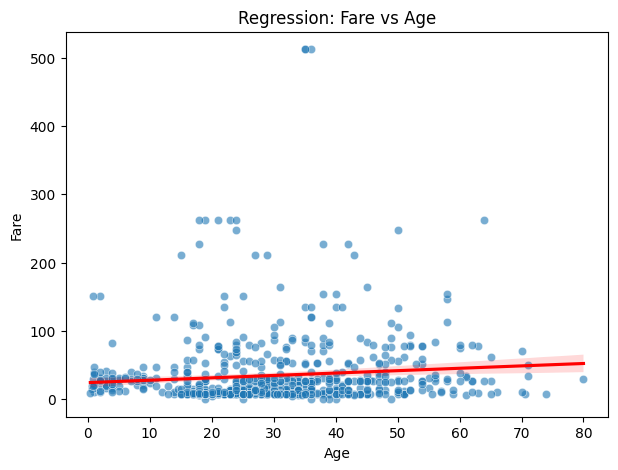

In [ ]:
# Visualization: Scatter + Regression Line
plt.figure(figsize=(7,5))
sns.scatterplot(x="Age", y="Fare", data=df_clean, alpha=0.6)
sns.regplot(x="Age", y="Fare", data=df_clean, scatter=False, color="red")
plt.title("Regression: Fare vs Age")
plt.show()

###  Summary

In [ ]:

print("\nSummary:")
print("- Descriptive stats told us survival rate in the dataset.")
print("- Inferential stats (confidence intervals) let us estimate population survival rate.")
print("- Hypothesis tests showed survival depended on class, and compared ages by gender.")
print("- Regression explored relation between Age and Fare.")


Summary:
- Descriptive stats told us survival rate in the dataset.
- Inferential stats (confidence intervals) let us estimate population survival rate.
- Hypothesis tests showed survival depended on class, and compared ages by gender.
- Regression explored relation between Age and Fare.


array([ 0.67126976, -1.56442901, -0.54598746,  1.29769767, -1.41405285,
       -0.03297055,  0.87722989, -0.93411698,  1.43588985, -1.23108923])

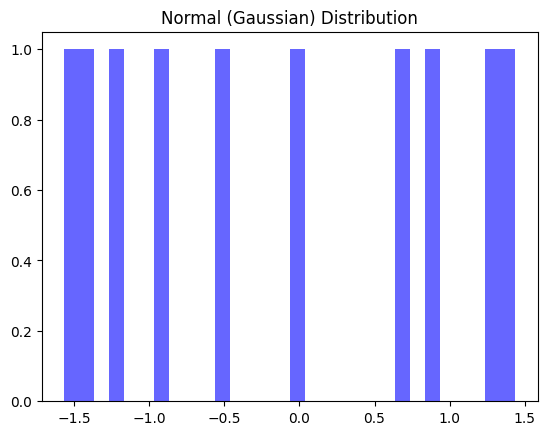

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

mu, sigma = 0, 1  # mean and standard deviation
data = np.random.normal(mu, sigma, 10)
display(data)
plt.hist(data, bins=30, density=True, alpha=0.6, color='b')
plt.title("Normal (Gaussian) Distribution")
plt.show()


In [ ]:
 np.random.normal?

In [ ]:
np.percentile?